# X-band Radio Light Curve: SN 2018ivc vs. Type IIb Comparison Sample

Spectral luminosity ($L_\nu$) vs. phase at X-band (8-12 GHz), comparing SN 2018ivc
to the 6 Type IIb SNe with the most X-band coverage (>=10 points): SN1993J,
SN2003bg, SN2001ig, SN2016gkg, SN2001gd, SN2011hs. SN2018ivc is included
regardless of its point count (8 points) since it's the reference object.

Flux density is converted to spectral luminosity ($L_\nu = 4\pi D^2 F_\nu$) using
distances sourced per-SN from the literature (see `data/sn_reference_crosswalk.xlsx`,
`distance_Mpc` / `distance_source` columns). SN2018ivc uses a direct Cepheid
distance to NGC 1068 (10.72 Mpc, arXiv:2602.22407) rather than its Hubble-flow
redshift distance (~16.2 Mpc at z=0.003793), since NGC 1068's peculiar velocity
makes the redshift distance unreliable (see crosswalk row for details).

Color encodes SN identity (categorical palette) rather than frequency, since only
one band is shown here -- the turbo/LogNorm frequency convention in
`CLAUDE_plotting.md` doesn't apply to this single-band, multi-SN comparison.
SN2018ivc gets a distinct marker shape and larger size so it stands out from the
comparison sample at a glance.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import functions

functions.set_plot_style()

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

# --- Comparison sample: >=10 X-band points (see conversation record for the
# point-count survey). SN2018ivc is always included regardless of count.
COMPARISON_SNE = ["SN1993J", "SN2003bg", "SN2001ig", "SN2016gkg", "SN2001gd", "SN2011hs"]
ALL_SNE = COMPARISON_SNE + ["SN2018ivc"]

XBAND_LO, XBAND_HI = 8.0, 12.0  # GHz

# --- Load per-SN distances from the reference crosswalk ---
crosswalk = pd.read_excel(
    "../data/sn_reference_crosswalk.xlsx", sheet_name="Figure 8 References"
)
crosswalk["SN_key"] = crosswalk["Supernova"].str.replace(" ", "", regex=False)
dist_lookup = crosswalk.set_index("SN_key")["distance_Mpc"].to_dict()

for sn in ALL_SNE:
    assert sn in dist_lookup and not pd.isna(dist_lookup[sn]), f"missing distance for {sn}"

# --- Load and filter X-band data for every SN in the comparison ---
frames = []
for sn in ALL_SNE:
    fname = "../data/radio_18ivc_data.csv" if sn == "SN2018ivc" else f"../data/{sn}_radio_data.csv"
    df = pd.read_csv(fname)
    df = df[(df["freq"] >= XBAND_LO) & (df["freq"] < XBAND_HI)].copy()
    df["SN"] = sn
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

print(data.groupby("SN").size().reindex(ALL_SNE))

SN
SN1993J      112
SN2003bg      42
SN2001ig      32
SN2016gkg     14
SN2001gd      13
SN2011hs      10
SN2018ivc      8
dtype: int64


In [2]:
# --- Flux density -> spectral luminosity ---
MPC_TO_CM = 3.0857e24
MJY_TO_ERG_S_CM2_HZ = 1e-26

def flux_to_luminosity(flux_mjy, distance_mpc):
    F_nu = flux_mjy * MJY_TO_ERG_S_CM2_HZ
    D_cm = distance_mpc * MPC_TO_CM
    return 4 * np.pi * D_cm**2 * F_nu

data["distance_Mpc"] = data["SN"].map(dist_lookup)
data["L_nu"] = flux_to_luminosity(data["flux"], data["distance_Mpc"])
data["L_nu_err"] = flux_to_luminosity(data["flux_err"].fillna(0), data["distance_Mpc"])

data.head()

,phase,freq,flux,flux_err,telescope,SN,distance_Mpc,L_nu,L_nu_err
0,3.10,8.4,0.09,NaN,VLA,SN1993J,3.63,1.418969e+24,0.000000e+00
1,5.30,8.4,0.12,NaN,VLA,SN1993J,3.63,1.891959e+24,0.000000e+00
2,11.37,8.4,0.75,0.063,VLA,SN1993J,3.63,1.182474e+25,9.932786e+23
3,13.04,8.4,1.33,0.097,VLA,SN1993J,3.63,2.096921e+25,1.529334e+24
4,14.25,8.4,1.89,0.107,VLA,SN1993J,3.63,2.979836e+25,1.686997e+24


In [3]:
# --- Style setup: color by SN identity (categorical), not frequency ---
# One color per SN from tab10, in a fixed order so colors stay stable if SNe are
# added/removed from the comparison sample later.
tab10 = mpl.colormaps["tab10"]
SN_COLOR = {sn: tab10(i) for i, sn in enumerate(COMPARISON_SNE)}
SN_COLOR["SN2018ivc"] = "#000000"  # reserved: solid black, maximally distinct from tab10

COMPARISON_MS = 8
COMPARISON_MARKER = "o"


def plot_comparison_sne(ax, ms_scale=1.0):
    """Plot the 6 comparison SNe with the shared circle marker."""
    for sn in COMPARISON_SNE:
        d_sn = data[data["SN"] == sn].sort_values("phase")
        color = SN_COLOR[sn]
        edge = darken_color(color, 0.7)
        ax.errorbar(
            d_sn["phase"], d_sn["L_nu"], yerr=d_sn["L_nu_err"],
            fmt=COMPARISON_MARKER, ms=COMPARISON_MS * ms_scale,
            capsize=3 * ms_scale, elinewidth=1.3 * ms_scale,
            linestyle="none", color=color, markeredgecolor=edge,
            alpha=0.85, label=sn, zorder=3,
        )


def plot_2018ivc(ax, marker="*", ms=22, markeredgewidth=1.5, ms_scale=1.0):
    """Plot SN2018ivc with a distinct marker/size so it stands out."""
    d_sn = data[data["SN"] == "SN2018ivc"].sort_values("phase")
    color = SN_COLOR["SN2018ivc"]
    ax.errorbar(
        d_sn["phase"], d_sn["L_nu"], yerr=d_sn["L_nu_err"],
        fmt=marker, ms=ms * ms_scale,
        capsize=4 * ms_scale, elinewidth=1.8 * ms_scale,
        markeredgewidth=markeredgewidth, linestyle="none",
        color=color, markeredgecolor="0.3",
        alpha=0.95, label="SN2018ivc", zorder=5,
    )

## Marker-style options for SN2018ivc

Three candidate styles, shown side by side, before committing to one for the
final figure.

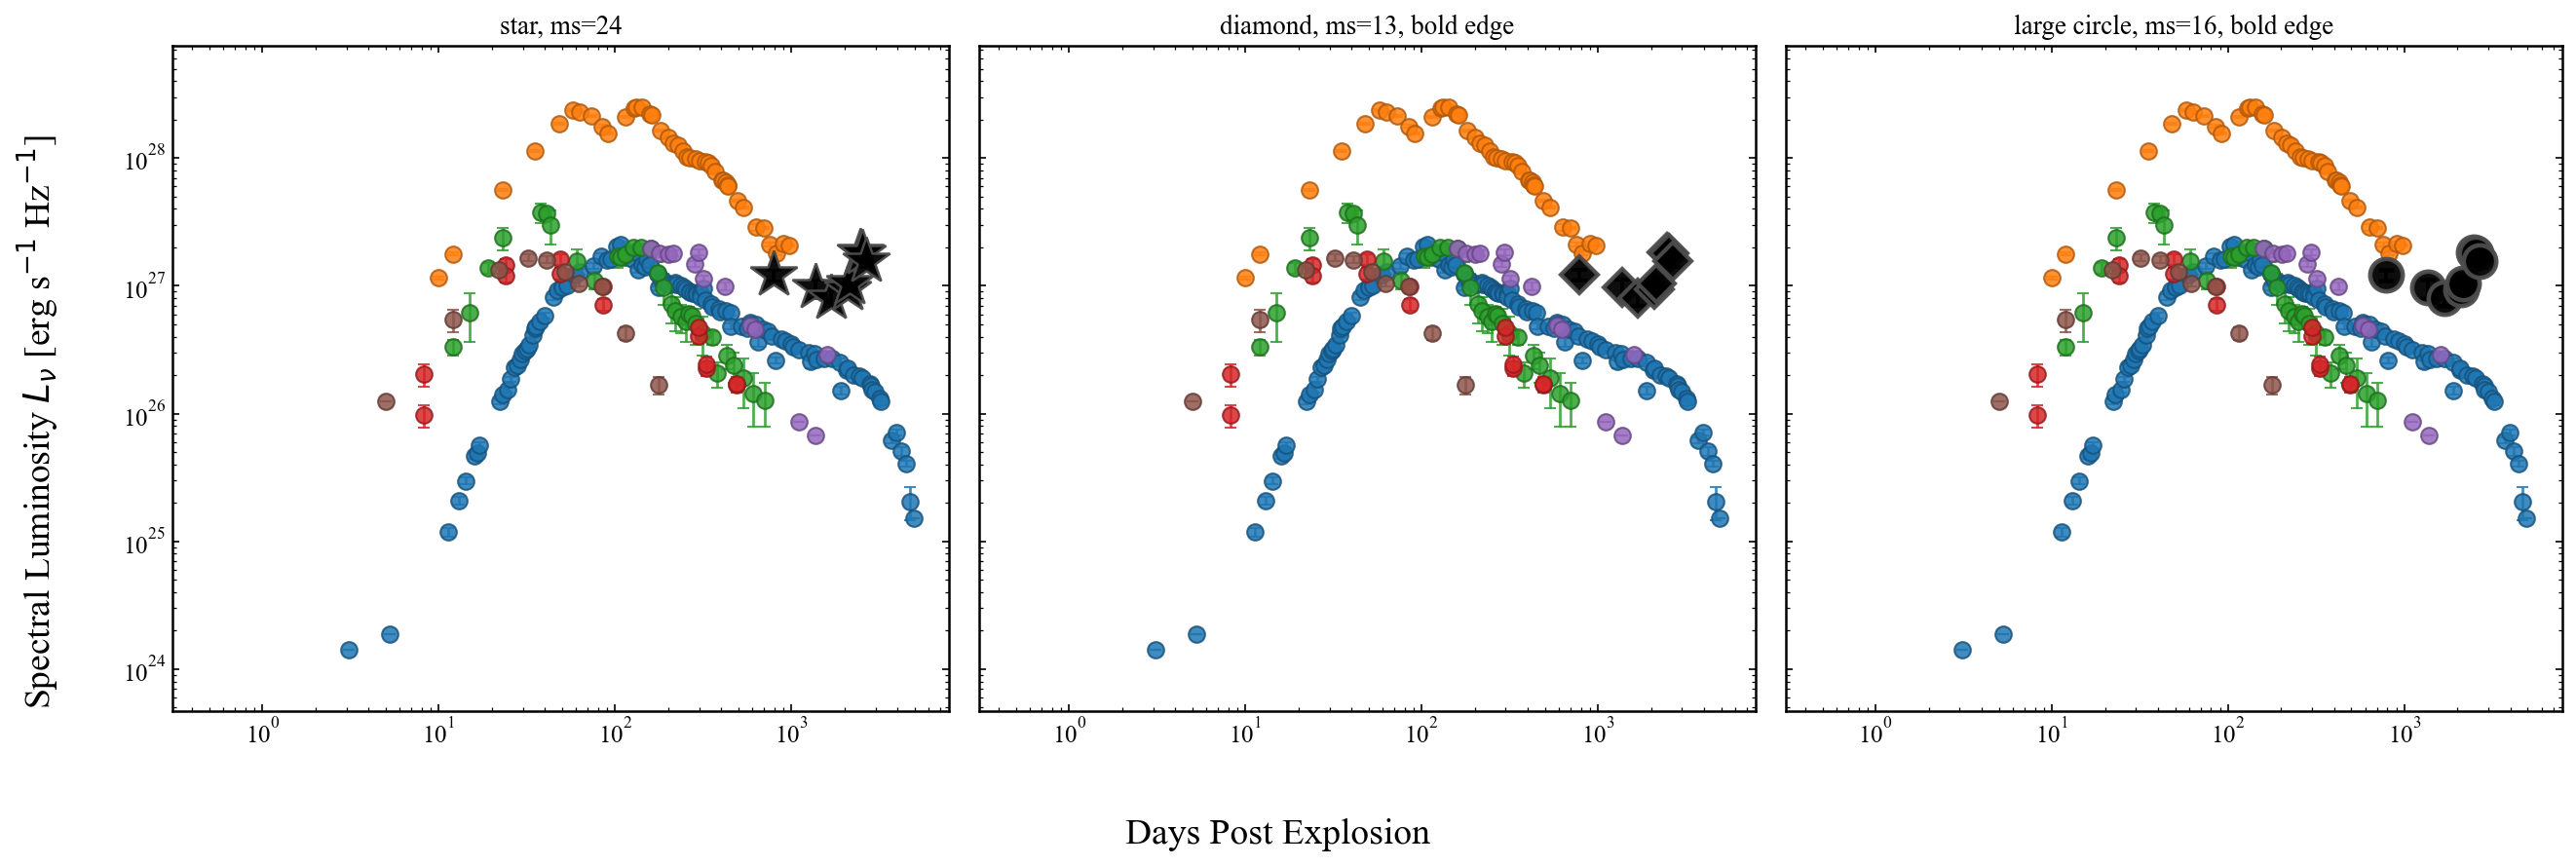

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150, sharex=True, sharey=True)

variants = [
    dict(marker="*", ms=24, markeredgewidth=1.2, label="star, ms=24"),
    dict(marker="D", ms=13, markeredgewidth=2.0, label="diamond, ms=13, bold edge"),
    dict(marker="o", ms=16, markeredgewidth=2.2, label="large circle, ms=16, bold edge"),
]

ylo = data["L_nu"].min() / 3
yhi = data["L_nu"].max() * 3

for ax, variant in zip(axes, variants):
    plot_comparison_sne(ax)
    plot_2018ivc(
        ax, marker=variant["marker"], ms=variant["ms"],
        markeredgewidth=variant["markeredgewidth"],
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(ylo, yhi)
    ax.set_title(variant["label"], fontsize=13)

fig.supxlabel("Days Post Explosion", fontsize=18)
fig.supylabel(r"Spectral Luminosity $L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]", fontsize=18)
fig.tight_layout(rect=[0.02, 0.02, 1, 1])
plt.show()

## Final figure

Using the star marker (largest visual separation from the comparison sample's
circles at a glance, and consistent with the existing "this work" star
convention from `sed_epoch_grid.ipynb`).

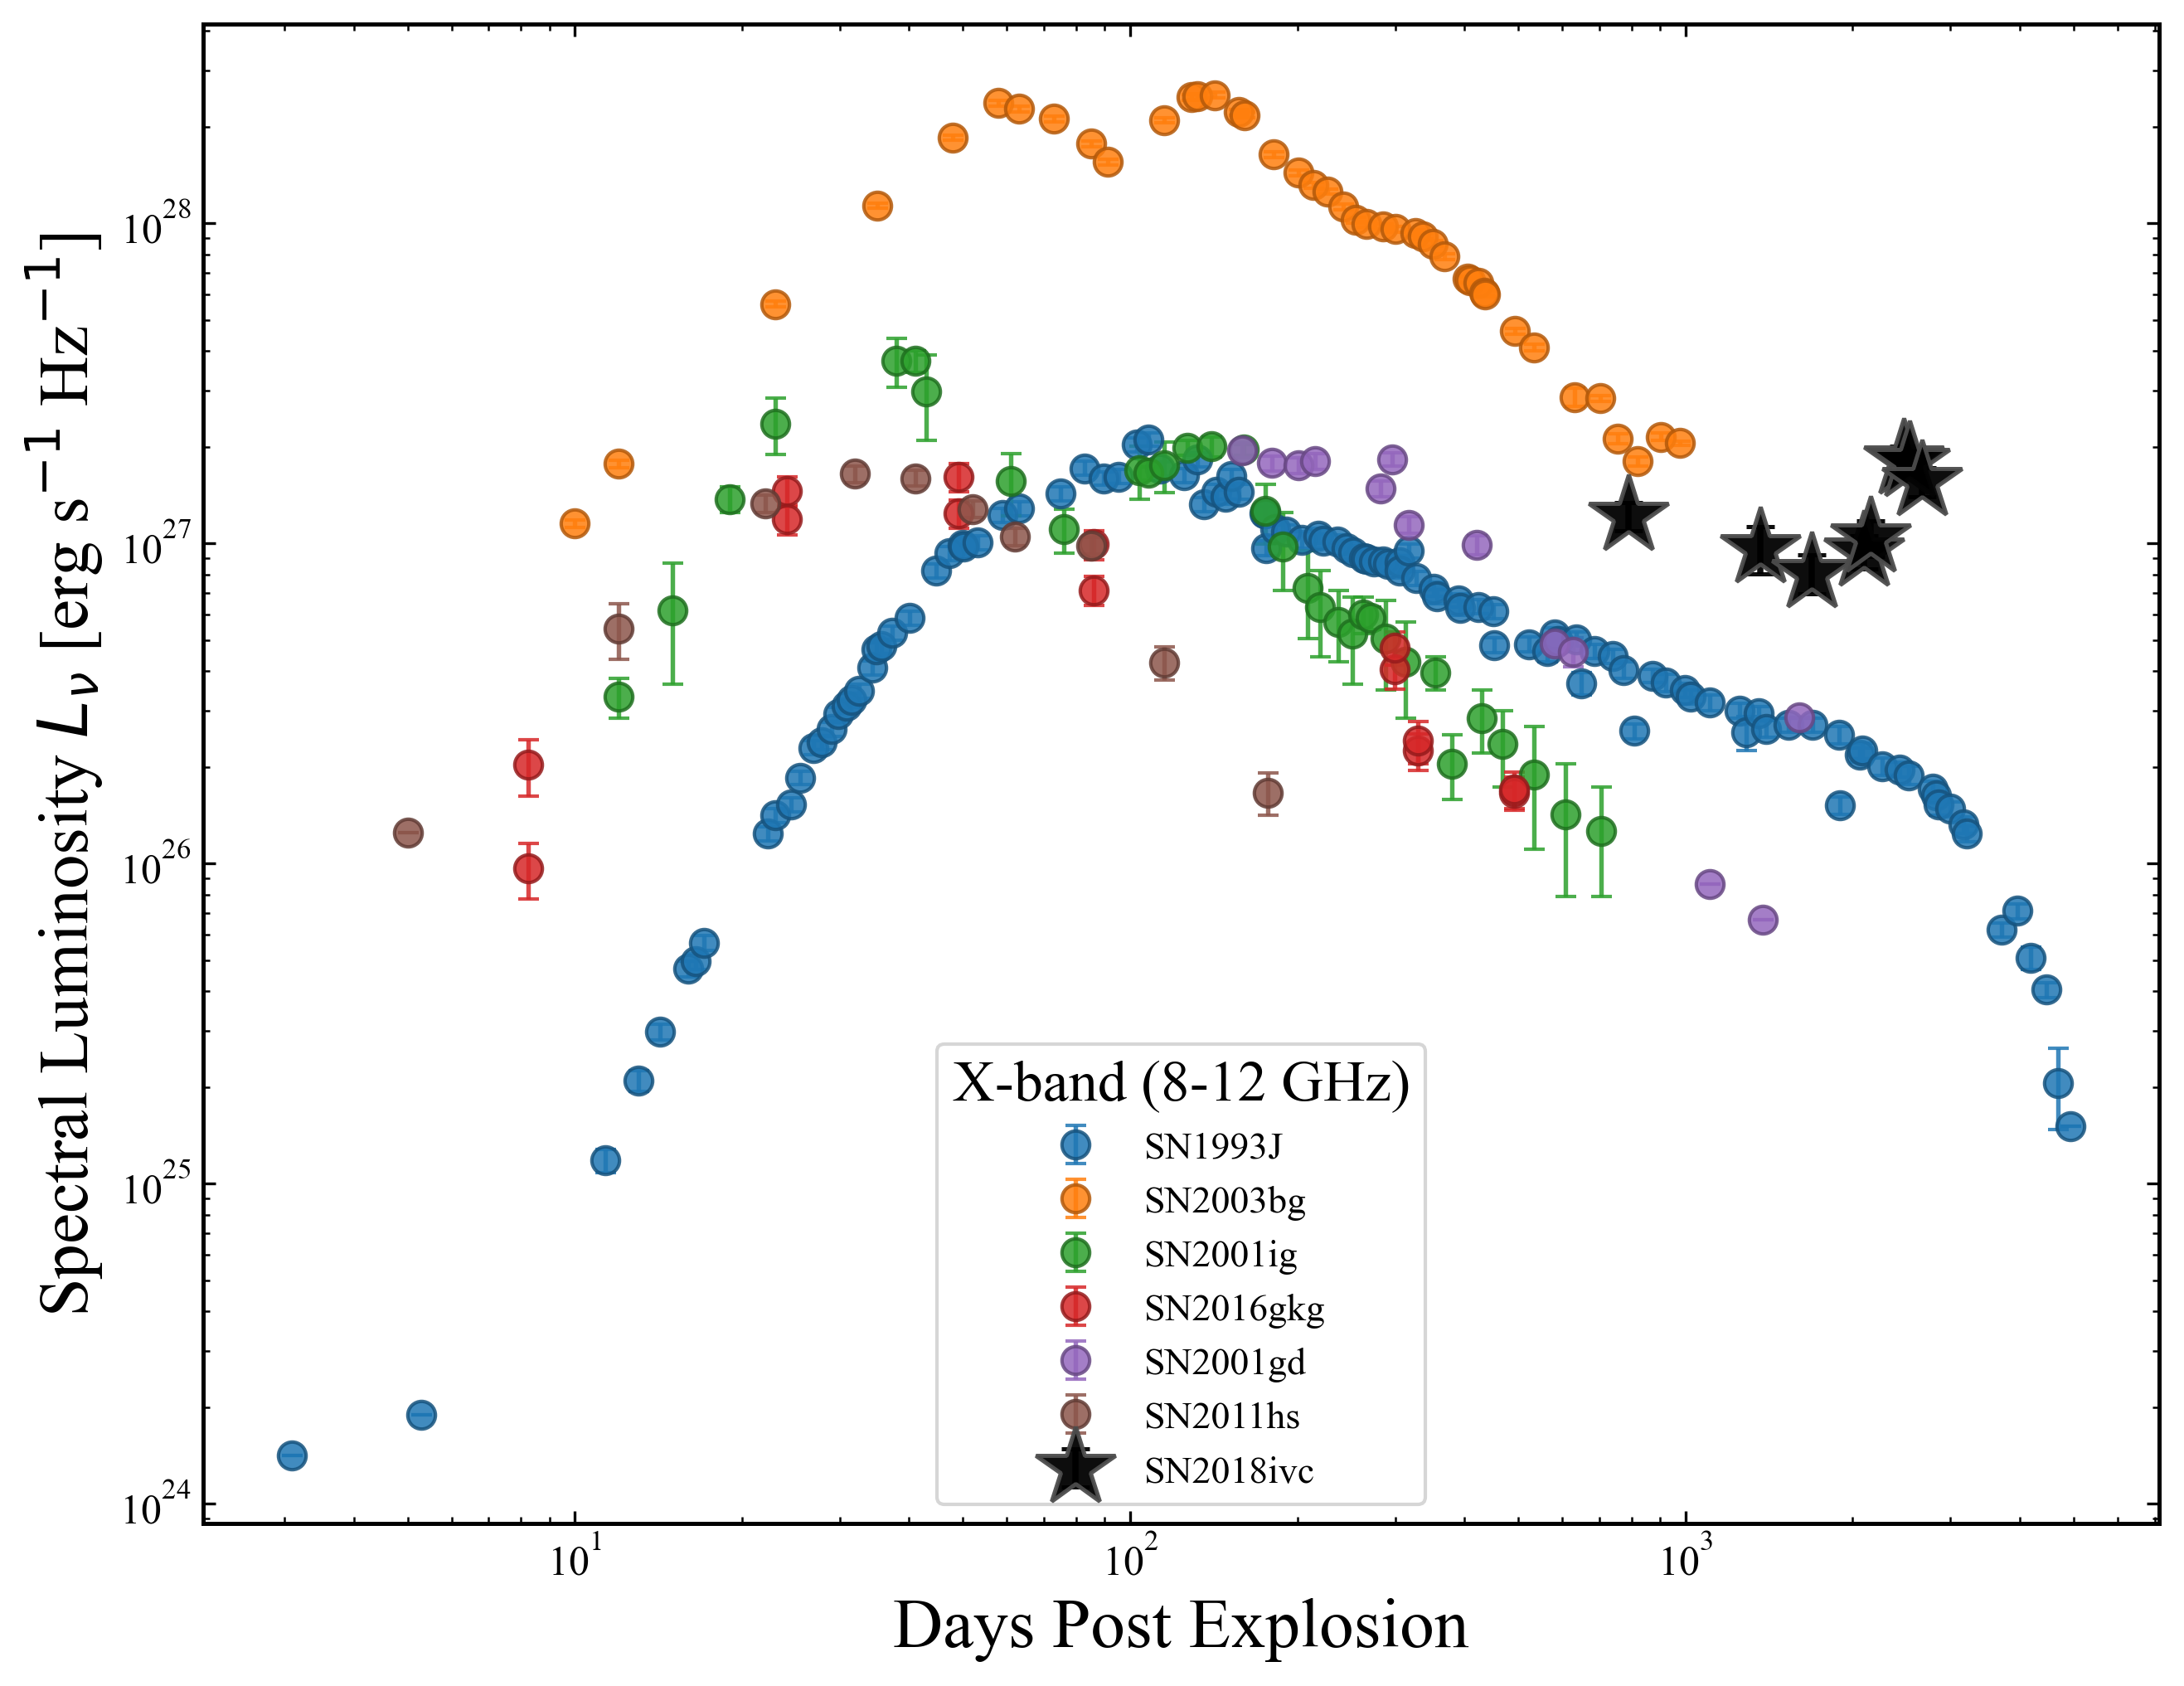

In [5]:
fig, ax = plt.subplots(dpi=300, figsize=(9, 7))

plot_comparison_sne(ax)
plot_2018ivc(ax, marker="*", ms=24, markeredgewidth=1.2)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Days Post Explosion", fontsize=20)
ax.set_ylabel(r"Spectral Luminosity $L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]", fontsize=20)

ax.legend(title="X-band (8-12 GHz)", title_fontsize="large", fontsize=11, frameon=True)

fig.tight_layout()

fig.savefig("../figures/radio_lc_IIb_comparison_Xband.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/radio_lc_IIb_comparison_Xband.pdf", bbox_inches="tight")

plt.show()